# 0. Carregando Camada Prata

In [10]:
#Conjunto de Imports para funcionamento de todas as células do notebook
import os
import urllib.request
from pathlib import Path
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import countDistinct
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from pyspark.sql.functions import min as spark_min, max as spark_max, col
import seaborn as sns
from pyspark.sql.types import DoubleType
from pyspark.sql.types import IntegerType

In [11]:
import sys, os
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [13]:
# 0. LEITURA DA CAMADA SILVER (PARQUET)
#Início da engine para o projeto
spark = SparkSession.builder.appName("eda_taxi") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "false") \
    .getOrCreate()

path_silver = Path(os.getcwd()) / "data/2_Silver/yellow_trips_silver/silver.parquet"
df_prata = spark.read.parquet(str(path_silver))

KeyboardInterrupt: 

In [14]:
import sys
print("Python do kernel:", sys.version)
print("Executável:", sys.executable)

import pyspark
print("PySpark:", pyspark.__version__)
print("PySpark em:", pyspark.__file__)

import os
print("PYSPARK_PYTHON:", os.environ.get("PYSPARK_PYTHON"))
print("PYSPARK_DRIVER_PYTHON:", os.environ.get("PYSPARK_DRIVER_PYTHON"))

Python do kernel: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
Executável: c:\Users\danil\anaconda3\envs\datasus\python.exe
PySpark: 4.2.0
PySpark em: c:\Users\danil\anaconda3\envs\datasus\Lib\site-packages\pyspark\__init__.py
PYSPARK_PYTHON: c:\Users\danil\anaconda3\envs\datasus\python.exe
PYSPARK_DRIVER_PYTHON: c:\Users\danil\anaconda3\envs\datasus\python.exe


# 1. Definindo e Criando as Dimensões

## Documentação de Arquitetura e Modelagem Dimensional (Camada Ouro)

Este documento descreve a estratégia de modelagem analítica aplicada sobre a Camada Silver dos dados de corridas de táxi de Nova York (NYC Yellow Taxi), utilizando a metodologia de **Esquema Estrela (Star Schema)** proposta por Ralph Kimball.

---

## 1. Definição do Processo de Negócio

O processo de negócio modelado é a **Realização de Viagens de Táxi e Faturamento**. O objetivo principal do Data Warehouse é permitir que analistas, gestores e cientistas de dados realizem análises de:
* Eficiência operacional (duração, velocidade e distância).
* Padrões de consumo e meios de pagamento preferidos.
* Faturamento, taxas regulatórias e receita de gorjetas.
* Comportamento e demanda por períodos temporais.

---

## 2. Escolha da Granularidade

> **Granularidade Adotada:** **1 linha = 1 corrida de táxi realizada.**

### Justificativa da Decisão:
* **Preservação de Sinal (Atomicidade):** Optou-se pela **granularidade atômica** (o nível mais detalhado possível fornecido pela fonte). Não agregamos os dados por dia ou bairro na Fato.
* **Flexibilidade Total em OLAP:** Manter cada transação individual permite que as ferramentas de BI realizem *drill-down* e *roll-up* para qualquer nível de agregação desejado (por hora, por dia, por meio de pagamento ou por faixa de distância) sem perda de informação.
* **Preservação de Flags de Auditoria:** Permite analisar anomalias e *status* de qualidade que foram tratados na Camada Silver em nível de transação.

---

## 3. Estrutura do Esquema Estrela (Star Schema)

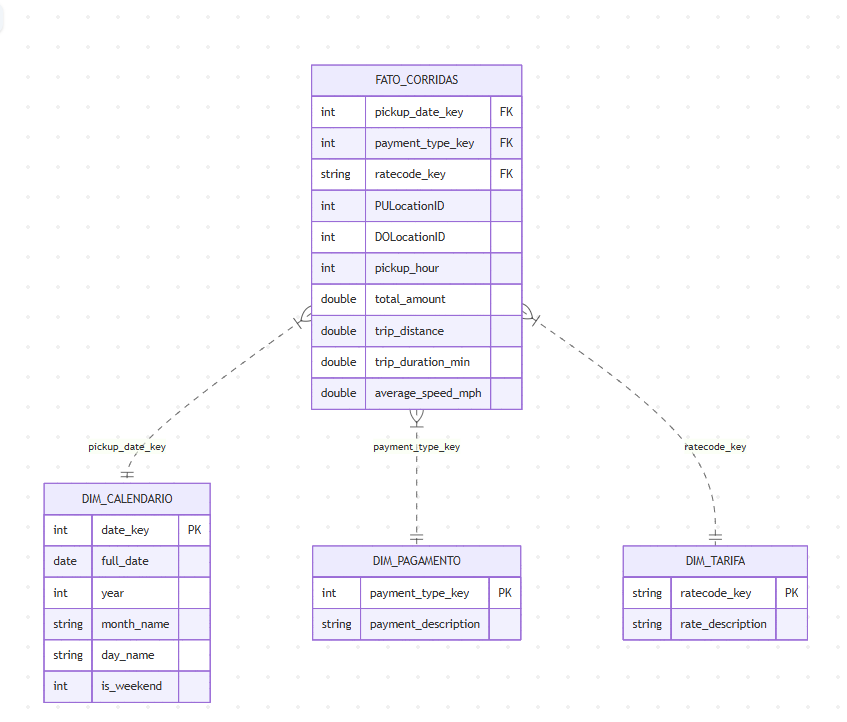

---

## 4. Justificativa e Especificação das Tabelas

### 4.1 Tabela Fato: `Fato_Corridas`
A Fato centraliza as **métricas quantitativas (fatos)** do evento de negócio e armazena as **Chaves Estrangeiras (FKs)** que se conectam às dimensões.

* **Chaves Estrangeiras (FKs):**
  * `pickup_date_key`: Chave inteira no formato `YYYYMMDD` conectando com a `Dim_Calendario`.
  * `payment_type_key`: Código do meio de pagamento.
  * `ratecode_key`: Código do tipo de tarifa aplicada.
  * `PULocationID` / `DOLocationID`: IDs numéricos das zonas de embarque e desembarque.
* **Métricas Financeiras (Soma/Média):** `fare_amount`, `extra`, `mta_tax`, `tip_amount`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`, `Airport_fee`, `total_amount`, `calculated_total`, `total_diff`.
* **Métricas Físicas e Derivadas:** `passenger_count`, `trip_distance`, `trip_duration_min`, `average_speed_mph`, `cost_per_mile`.
* **Atributos de Qualidade (Prata):** Mantidos na fato (`tip_amount_status`, `passenger_count_status`, etc.) para permitir filtrar rapidamente viagens auditadas ou com discrepâncias.

---

### 4.2 Tabelas Dimensão (Contexto do Negócio)

#### 📅 `Dim_Calendario`
* **Motivação:** Evita o custo computacional de aplicar funções de data (`YEAR()`, `MONTH()`, `DAYOFWEEK()`) repetidamente em uma Fato com milhões de linhas.
* **Uso da Surrogate Key (`date_key`):** Utilizou-se um inteiro `YYYYMMDD` (ex: `20240115`) em vez de um campo `TIMESTAMP` ou `DATE`. JOINs entre números inteiros possuem melhor performance e otimização de memória no Spark e bancos de dados colunares.
* **Atributos Derivados:** `year`, `month`, `month_name`, `day_of_month`, `day_of_week`, `day_name`, `quarter` e o flag binário `is_weekend` (facilita separar dias úteis de fins de semana).

#### 💳 `Dim_Pagamento`
* **Motivação:** Normalização dos códigos numéricos (`1`, `2`, `3`, `4`) para descrições legíveis de negócio (`Credit card`, `Cash`, `No charge`, `Dispute`).
* **Benefício:** Evita a duplicação de strings descritivas na Fato, reduzindo o tamanho do armazenamento em disco (compressão Parquet/Delta).

#### 🏷️ `Dim_Tarifa`
* **Motivação:** Mapeia os códigos do campo `RatecodeID` (`1` a `6`, e `99`) para seus nomes operacionais reais (`Standard rate`, `JFK`, `Newark`, etc.).
* **Decisão de Tipo:** Convertido para `string` para aceitar com segurança códigos não convencionais como o `99` (Tarifa de Teste/Especial).

---

## 5. Resumo das Decisões de Engenharia e Performance

1. **Tipagem Adequada para Chaves de JOIN:**
   * Garantia de que todas as chaves primárias e estrangeiras de conexão fossem inteiros (`IntegerType`) ou strings padronizadas, eliminando falhas de *type mismatch* no Spark.
2. **Otimização de Armazenamento (Storage Efficiency):**
   * Remoção de colunas temporais redundantes da Fato (como o `dropoff_datetime`), mantendo a duração tratada (`trip_duration_min`).
3. **Compatibilidade com BI:**
   * O modelo foi desenhado no formato estritamente **Star Schema**, permitindo importação direta

In [ ]:

# 1. DIM_CALENDARIO (Ajustada exatamente para Jan/2024)

df_dates = spark.sql("SELECT explode(sequence(to_date('2024-01-01'), to_date('2024-01-31'), interval 1 day)) as full_date")

dim_calendario = df_dates \
    .withColumn("date_key", F.date_format("full_date", "yyyyMMdd").cast(IntegerType())) \
    .withColumn("year", F.year("full_date")) \
    .withColumn("month", F.month("full_date")) \
    .withColumn("month_name", F.lit("Janeiro")) \
    .withColumn("day_of_month", F.dayofmonth("full_date")) \
    .withColumn("day_of_week", F.dayofweek("full_date")) \
    .withColumn("day_name", F.date_format("full_date", "EEEE")) \
    .withColumn("quarter", F.quarter("full_date")) \
    .withColumn("is_weekend", F.when(F.dayofweek("full_date").isin(1, 7), 1).otherwise(0))


# 2. DIM_PAGAMENTO (Mapeamento dos códigos 1, 2, 3, 4 encontrados)

pagamento_data = [
    (1, "Credit card"),
    (2, "Cash"),
    (3, "No charge"),
    (4, "Dispute"),
    (5, "Unknown"),
    (6, "Voided trip")
]
dim_pagamento = spark.createDataFrame(pagamento_data, ["payment_type_key", "payment_description"])


# 3. DIM_TARIFA (Mapeamento dos códigos de RatecodeID do dataset)

tarifa_data = [
    ("1", "Standard rate"),
    ("2", "JFK"),
    ("3", "Newark"),
    ("4", "Nassau or Westchester"),
    ("5", "Negotiated fare"),
    ("6", "Group ride"),
    ("99", "Special / Test Rate")
]
dim_tarifa = spark.createDataFrame(tarifa_data, ["ratecode_key", "rate_description"])

# 2. Criando a FATO

In [ ]:
# 4. FATO_CORRIDAS (Unindo métricas e chaves das dimensões)

fato_corridas = df_prata \
    .withColumn("pickup_date_key", F.date_format("tpep_pickup_datetime", "yyyyMMdd").cast(IntegerType())) \
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime")) \
    .withColumn("ratecode_key", F.col("RatecodeID").cast("string")) \
    .withColumn("payment_type_key", F.col("payment_type").cast(IntegerType())) \
    .select(
        # Chaves Estrangeiras (FKs) para se ligar com as Dimensões
        "pickup_date_key",
        "payment_type_key",
        "ratecode_key",
        "PULocationID",
        "DOLocationID",
        "VendorID",

        # Atributos de Tempo / Horário
        "pickup_hour",

        # Métricas Físicas e de Desempenho
        "passenger_count",
        "trip_distance",
        "trip_duration_min",
        "average_speed_mph",
        "cost_per_mile",

        # Métricas Financeiras (Valores)
        "fare_amount",
        "extra",
        "mta_tax",
        "tip_amount",
        "tolls_amount",
        "improvement_surcharge",
        "congestion_surcharge",
        "Airport_fee",
        "total_amount",

        # Colunas de Auditoria / Status da Prata
        "passenger_count_status",
        "congestion_surcharge_status",
        "Airport_fee_status",
        "average_speed_mph_status"
    )

# Visualizando a Fato Ouro
fato_corridas.show(5, truncate=False)

+---------------+----------------+------------+------------+------------+--------+-----------+---------------+-------------+------------------+------------------+-----------------+-----------+-----+-------+----------+------------+---------------------+--------------------+-----------+------------+----------------------+---------------------------+------------------+------------------------+
|pickup_date_key|payment_type_key|ratecode_key|PULocationID|DOLocationID|VendorID|pickup_hour|passenger_count|trip_distance|trip_duration_min |average_speed_mph |cost_per_mile    |fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|congestion_surcharge|Airport_fee|total_amount|passenger_count_status|congestion_surcharge_status|Airport_fee_status|average_speed_mph_status|
+---------------+----------------+------------+------------+------------+--------+-----------+---------------+-------------+------------------+------------------+-----------------+-----------+-----+-------+------

# 3. Load Camanda Gold - StarSchema

In [ ]:
from pathlib import Path
import os

path_gold = Path(os.getcwd()) / "data" / "3_gold"

# --- Dimensões: pequenas, gravam via pandas de uma vez ---
dimensoes = {
    "dim_calendario": dim_calendario,
    "dim_pagamento": dim_pagamento,
    "dim_tarifa": dim_tarifa,
}
for nome, dframe in dimensoes.items():
    pasta = path_gold / nome
    pasta.mkdir(parents=True, exist_ok=True)
    dframe.toPandas().to_parquet(
        str(pasta / "part-000.parquet"),
        index=False, coerce_timestamps="us", allow_truncated_timestamps=True
    )
    print(f"✅ {nome}")

# --- Fato: grande, gravada em pedaços para não estourar a memória ---
pasta_fato = path_gold / "fato_corridas"
pasta_fato.mkdir(parents=True, exist_ok=True)

N_PEDACOS = 12  # divide a fato em 12 partes
fato_particionada = fato_corridas.repartition(N_PEDACOS)
partes = fato_particionada.rdd.glom().toLocalIterator()

for i, linhas in enumerate(partes):
    if not linhas:
        continue
    import pandas as pd
    pdf = pd.DataFrame(linhas, columns=fato_corridas.columns)
    pdf.to_parquet(
        str(pasta_fato / f"part-{i:03d}.parquet"),
        index=False, coerce_timestamps="us", allow_truncated_timestamps=True
    )
    print(f"   fato: pedaço {i+1}/{N_PEDACOS} gravado ({len(linhas)} linhas)")

print("✅ fato_corridas (em pedaços)")


✅ dim_calendario


Py4JJavaError: An error occurred while calling o93.collectToPython.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 10 in stage 5.0 failed 1 times, most recent failure: Lost task 10.0 in stage 5.0 (TID 29) (DaniloPC executor driver): org.apache.spark.SparkException: Python worker exited unexpectedly (crashed)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:612)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator$$anonfun$1.applyOrElse(PythonRunner.scala:594)
	at scala.runtime.AbstractPartialFunction.apply(AbstractPartialFunction.scala:38)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:789)
	at org.apache.spark.api.python.PythonRunner$$anon$3.read(PythonRunner.scala:766)
	at org.apache.spark.api.python.BasePythonRunner$ReaderIterator.hasNext(PythonRunner.scala:525)
	at org.apache.spark.InterruptibleIterator.hasNext(InterruptibleIterator.scala:37)
	at scal

# 4. OLAP - Consultas e Validação

## 4.1 Usando PySpark (Sintaxe de Dataframe)

In [ ]:
# Exemplo OLAP: Receita total e Gorjeta Média por Tipo de Pagamento
olap_pagamento = fato_corridas.join(dim_pagamento, "payment_type_key") \
    .groupBy("payment_description") \
    .agg(
        F.count("*").alias("total_corridas"),
        F.round(F.sum("total_amount"), 2).alias("receita_total"),
        F.round(F.avg("tip_amount"), 2).alias("gorjeta_media")
    ) \
    .orderBy(F.desc("receita_total"))

olap_pagamento.show(truncate=False)

+-------------------+--------------+-------------+-------------+
|payment_description|total_corridas|receita_total|gorjeta_media|
+-------------------+--------------+-------------+-------------+
|Credit card        |2286853       |6.561454073E7|4.21         |
|Cash               |420940        |1.021357518E7|0.0          |
|No charge          |8493          |186350.99    |0.0          |
|Dispute            |6637          |160046.48    |0.01         |
+-------------------+--------------+-------------+-------------+



## 4.2 Usando SQL Nativo (A experiência OLAP/DW)

In [ ]:
# 1. Registrando as tabelas no catálogo em memória do Spark
fato_corridas.createOrReplaceTempView("fato_corridas")
dim_calendario.createOrReplaceTempView("dim_calendario")
dim_pagamento.createOrReplaceTempView("dim_pagamento")
dim_tarifa.createOrReplaceTempView("dim_tarifa")

# 2. Executando uma consulta OLAP analítica em SQL
query_olap = spark.sql("""
    SELECT
        c.day_name AS dia_semana,
        c.is_weekend,
        t.rate_description AS tipo_tarifa,
        COUNT(f.pickup_date_key) AS total_viagens,
        ROUND(AVG(f.trip_distance), 2) AS dist_media_milhas,
        ROUND(AVG(f.trip_duration_min), 2) AS duracao_media_min,
        ROUND(SUM(f.total_amount), 2) AS faturamento_total
    FROM fato_corridas f
    JOIN dim_calendario c ON f.pickup_date_key = c.date_key
    JOIN dim_tarifa t     ON f.ratecode_key = t.ratecode_key
    GROUP BY
        c.day_name,
        c.is_weekend,
        t.rate_description
    ORDER BY
        faturamento_total DESC
""")

query_olap.show(20, truncate=False)

+----------+----------+---------------+-------------+-----------------+-----------------+-----------------+
|dia_semana|is_weekend|tipo_tarifa    |total_viagens|dist_media_milhas|duracao_media_min|faturamento_total|
+----------+----------+---------------+-------------+-----------------+-----------------+-----------------+
|Wednesday |0         |Standard rate  |438417       |2.54             |13.87            |1.102549785E7    |
|Tuesday   |0         |Standard rate  |405380       |2.53             |13.75            |1.01497835E7     |
|Thursday  |0         |Standard rate  |380608       |2.57             |14.16            |9675083.18       |
|Friday    |0         |Standard rate  |361517       |2.52             |13.46            |8935349.33       |
|Monday    |0         |Standard rate  |349768       |2.79             |13.03            |8819855.09       |
|Saturday  |1         |Standard rate  |371246       |2.43             |12.86            |8611688.77       |
|Sunday    |1         |Stand

## 4.3 Matriz / Tabela Dinâmica (Cube/Rollup)

In [ ]:
# Análise por Hora do Dia x Final de Semana
olap_pico = fato_corridas.join(dim_calendario, fato_corridas.pickup_date_key == dim_calendario.date_key) \
    .groupBy("is_weekend", "pickup_hour") \
    .agg(
        F.count("*").alias("volume_corridas"),
        F.round(F.avg("average_speed_mph"), 2).alias("velocidade_media")
    ) \
    .orderBy("is_weekend", "pickup_hour")

olap_pico.show(48, truncate=False)

+----------+-----------+---------------+----------------+
|is_weekend|pickup_hour|volume_corridas|velocidade_media|
+----------+-----------+---------------+----------------+
|0         |0          |35603          |16.35           |
|0         |1          |19476          |15.26           |
|0         |2          |13058          |14.8            |
|0         |3          |8950           |15.92           |
|0         |4          |6790           |18.7            |
|0         |5          |11872          |18.76           |
|0         |6          |29428          |15.21           |
|0         |7          |65244          |12.11           |
|0         |8          |90889          |10.1            |
|0         |9          |97247          |9.96            |
|0         |10         |99708          |9.89            |
|0         |11         |104481         |9.44            |
|0         |12         |110853         |9.69            |
|0         |13         |115720         |9.96            |
|0         |14

**Horário de Pico x Velocidade Média**

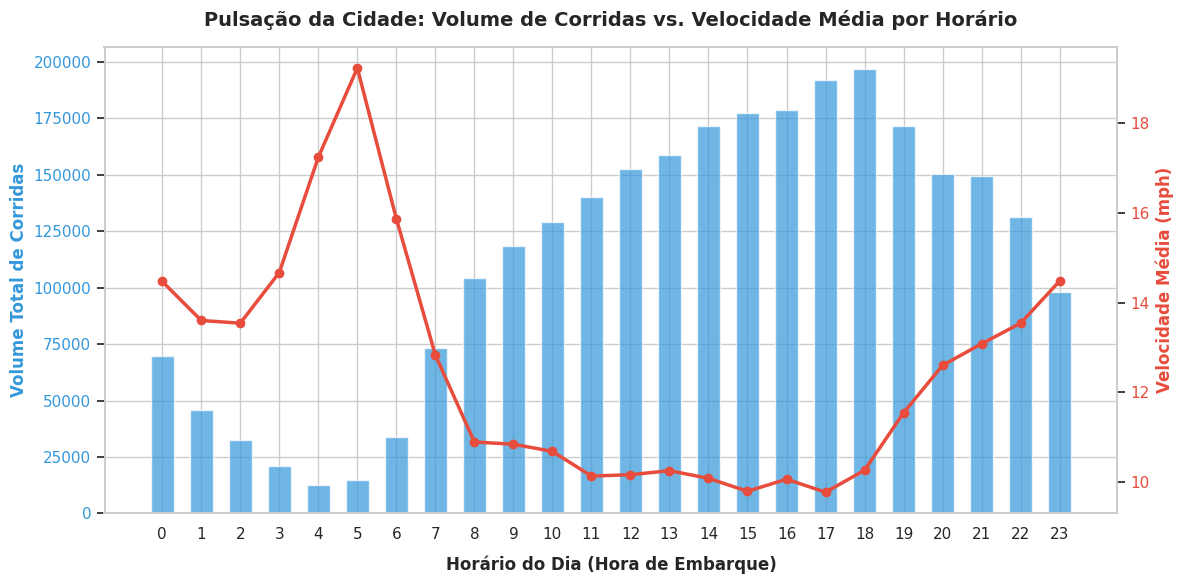

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set de estilo visual
sns.set_theme(style="whitegrid")

# 1. CONSULTA ANALÍTICA NA CAMADA OURO

fato_corridas.createOrReplaceTempView("fato_corridas")

df_pico_velocidade = spark.sql("""
    SELECT
        pickup_hour AS hora_do_dia,
        COUNT(*) AS total_corridas,
        ROUND(AVG(average_speed_mph), 2) AS velocidade_media_mph
    FROM fato_corridas
    GROUP BY pickup_hour
    ORDER BY pickup_hour ASC
""")

# Converter para Pandas para plotar no notebook
pdf = df_pico_velocidade.toPandas()

# 2. CONSTRUÇÃO DO GRÁFICO DE EIXO DUPLO

fig, ax1 = plt.subplots(figsize=(12, 6))

# Cor dos elementos
color_bar = '#3498db'  # Azul para o volume de corridas
color_line = '#e74c3c' # Vermelho para a velocidade média

# Eixo Y1 (Esquerda): Barras de Volume de Corridas
ax1.set_xlabel('Horário do Dia (Hora de Embarque)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Volume Total de Corridas', fontsize=12, color=color_bar, fontweight='bold')
bars = ax1.bar(pdf['hora_do_dia'], pdf['total_corridas'], color=color_bar, alpha=0.7, width=0.6, label='Volume de Corridas')
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_xticks(range(0, 24))

# Eixo Y2 (Direita): Linha de Velocidade Média
ax2 = ax1.twinx()
ax2.set_ylabel('Velocidade Média (mph)', fontsize=12, color=color_line, fontweight='bold')
line = ax2.plot(pdf['hora_do_dia'], pdf['velocidade_media_mph'], color=color_line, marker='o', linewidth=2.5, markersize=6, label='Velocidade Média (mph)')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.grid(False) # Desativa grid duplo para não poluir a imagem

# Título e Destaque
plt.title('Pulsação da Cidade: Volume de Corridas vs. Velocidade Média por Horário', fontsize=14, fontweight='bold', pad=15)

# Ajuste fino de layout
fig.tight_layout()

# Exibir no notebook
plt.show()

**Análise**

**O "Gargalo" da Cidade:** Note a grande queda na velocidade média ($\text{mph}$) durante as horas comerciais e início da noite ($14\text{h}$ às $18\text{h}$). É o momento em que a ilha de Manhattan atinge o pico de congestionamento urbano.

**Janela de Alta Eficiência Operacional:** Durante a madrugada ($02\text{h}$ às $05\text{h}$), os motoristas atingem as maiores velocidades médias (trânsito livre), cobrindo distâncias maiores em menos tempo.

**Decisão Tarifária:** Esse cruzamento justifica o motivo pelo qual cobranças adicionais de tráfego (como o `Congestion Surcharge`) são cruciais para compensar o tempo em que o motorista fica parado no trânsito lento.

**Dia Útil vs. Fim de Semana por Categoria de Tarifa**

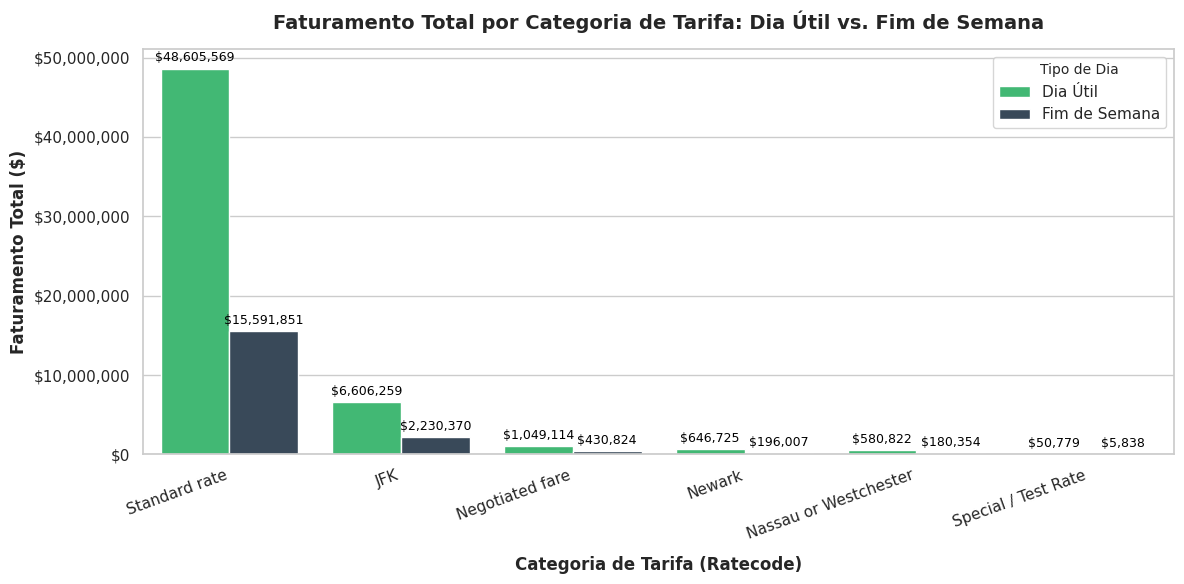

In [ ]:
# Configuração de estilo para apresentação
sns.set_theme(style="whitegrid")

# 1. CONSULTA ANALÍTICA NA CAMADA OURO

fato_corridas.createOrReplaceTempView("fato_corridas")
dim_calendario.createOrReplaceTempView("dim_calendario")
dim_tarifa.createOrReplaceTempView("dim_tarifa")

df_tarifa_semana = spark.sql("""
    SELECT
        t.rate_description AS tipo_tarifa,
        CASE
            WHEN c.is_weekend = 1 THEN 'Fim de Semana'
            ELSE 'Dia Útil'
        END AS tipo_dia,
        COUNT(*) AS total_corridas,
        ROUND(SUM(f.total_amount), 2) AS receita_total,
        ROUND(AVG(f.total_amount), 2) AS ticket_medio
    FROM fato_corridas f
    JOIN dim_calendario c ON f.pickup_date_key = c.date_key
    JOIN dim_tarifa t     ON f.ratecode_key = t.ratecode_key
    GROUP BY t.rate_description, c.is_weekend
    ORDER BY receita_total DESC
""")

# Converter para DataFrame Pandas para plotar
pdf_tarifa = df_tarifa_semana.toPandas()


# 2. CONSTRUÇÃO DO GRÁFICO DE BARRAS AGRUPADAS

plt.figure(figsize=(12, 6))

# Plotando com Seaborn
ax = sns.barplot(
    data=pdf_tarifa,
    x="tipo_tarifa",
    y="receita_total",
    hue="tipo_dia",
    palette=["#2ecc71", "#34495e"]  # Verde para Dia Útil, Escuro para Fim de Semana
)

# Formatação visual
plt.title('Faturamento Total por Categoria de Tarifa: Dia Útil vs. Fim de Semana', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoria de Tarifa (Ratecode)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Faturamento Total ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right')

# Formatar o eixo Y para valores em Moeda ($)
ax.yaxis.set_major_formatter('${x:,.0f}')

# Adicionar rótulos de valor nas barras para facilitar leitura rápida
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Evitar rótulos em barras nulas
        ax.annotate(f'${height:,.0f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, color='black',
                    xytext=(0, 3), textcoords='offset points')

plt.legend(title="Tipo de Dia", title_fontsize='10', loc='upper right')
plt.tight_layout()

# Exibir no notebook
plt.show()

**Heatmap de Eficiência Operacional.**

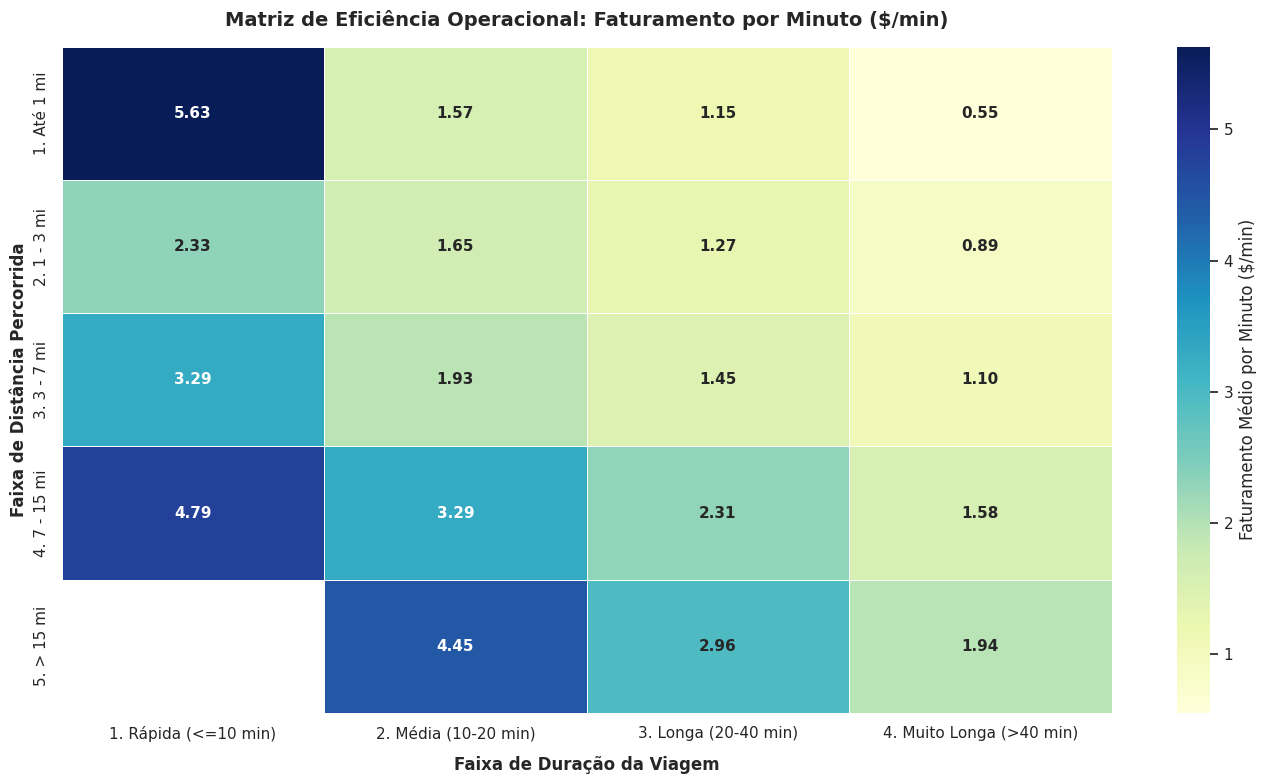

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
sns.set_theme(style="white")


# 1. CONSULTA ANALÍTICA NA CAMADA OURO

fato_corridas.createOrReplaceTempView("fato_corridas")

df_matriz_eficiencia = spark.sql("""
    SELECT
        CASE
            WHEN trip_distance <= 1.0 THEN '1. Até 1 mi'
            WHEN trip_distance <= 3.0 THEN '2. 1 - 3 mi'
            WHEN trip_distance <= 7.0 THEN '3. 3 - 7 mi'
            WHEN trip_distance <= 15.0 THEN '4. 7 - 15 mi'
            ELSE '5. > 15 mi'
        END AS faixa_distancia,

        CASE
            WHEN trip_duration_min <= 10.0 THEN '1. Rápida (<=10 min)'
            WHEN trip_duration_min <= 20.0 THEN '2. Média (10-20 min)'
            WHEN trip_duration_min <= 40.0 THEN '3. Longa (20-40 min)'
            ELSE '4. Muito Longa (>40 min)'
        END AS faixa_duracao,

        COUNT(*) AS total_corridas,
        ROUND(AVG(total_amount / trip_duration_min), 2) AS faturamento_por_minuto
    FROM fato_corridas
    WHERE trip_duration_min > 0 AND trip_distance > 0
    GROUP BY 1, 2
    ORDER BY 1, 2
""")

# Converter para Pandas
pdf_matriz = df_matriz_eficiencia.toPandas()


# 2. MONTAGEM DA TABELA DINÂMICA (PIVOT) PARA O HEATMAP
# Pivotando os dados para transformar em formato de Matriz (Linhas x Colunas)
pivot_faturamento = pdf_matriz.pivot(
    index="faixa_distancia",
    columns="faixa_duracao",
    values="faturamento_por_minuto"
)


# 3. CONSTRUÇÃO DO HEATMAP

plt.figure(figsize=(14, 8))

# Plotando o Mapa de Calor com anotações dos valores dentro dos blocos
ax = sns.heatmap(
    pivot_faturamento,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Faturamento Médio por Minuto ($/min)'},
    linewidths=.5,
    annot_kws={"size": 11, "weight": "bold"}
)

# Ajustes Visuais
plt.title('Matriz de Eficiência Operacional: Faturamento por Minuto ($/min)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faixa de Duração da Viagem', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Faixa de Distância Percorrida', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Insights de Negócio: Matriz de Eficiência Operacional ($/minuto)

A matriz acima cruza a **Faixa de Distância Percorrida** com a **Duração da Viagem** para avaliar a rentabilidade real do tempo do motorista ($ \text{Total Amount} / \text{Duração em Minutos} $).

---

#### Principais Conclusões de Negócio

1. **A Força da Bandeirada Inicial ($5.63 / min)**:

   * **Observação**: Corridas hipercurtas (**Até 1 mi**) concluídas em **menos de 10 minutos** geram o maior faturamento por minuto de toda a base ($5.63/min).

   * **Causa**: Isso ocorre devido à cobrança da **taxa mínima fixa de embarque (bandeirada)**. Em trajetos curtos sem retenção no trânsito, essa taxa fixa infla significativamente o ganho por tempo.

2. **O Trânsito Destrói a Rentabilidade ($0.55 / min)**:

   * **Observação**: Na coluna de viagens com duração **>40 minutos**, o faturamento por minuto despenca em todas as distâncias (atingindo a menor marca de $0.55/min nas viagens de até 1 mi).

   * **Causa**: Ficar preso no trânsito denso de Manhattan converte o tempo do motorista em prejuízo. Esse indicador justifica a necessidade das taxas regulatórias adicionais (*Congestion Surcharge*).

3. **O Quadrante de Ouro em Rodovias ($4.45 / min - $4.79 / min)**:

   * **Observação**: Viagens mais longas (**7 a 15 mi** e **>15 mi**) mantêm excelente rendimento quando concluídas em horários de fluxo livre ($4.79/min$ em <10 min e $4.45/min$ entre 10-20 min).

   * **Causa**: Corresponde tipicamente às rotas expressas para aeroportos (JFK e LaGuardia), onde a alta velocidade média compensa o tempo com tarifas acumuladas por quilometragem.

4. **Consistência e Qualidade dos Dados**:
   * **Observação**: A ausência de registros no quadrante de **>15 mi em <=10 min** valida o tratamento da Camada Silver.
   * **Causa**: Percorrer mais de 15 milhas em menos de 10 minutos exigiria uma velocidade média superior a **90 mph (~145 km/h)** no trânsito urbano, o que indicaria uma anomalia ou dado corrompido.

---

> **Resumo:**  
> *"A eficiência financeira no transporte de táxi em NYC não é determinada apenas pela distância, mas pela velocidade do fluxo. A taxa de embarque protege viagens curtas e ágeis, enquanto retenções superiores a 40 minutos reduzem a receita por minuto do motorista em até 90%."*